In [1]:
# ============================================================
# NASA C-MAPSS PROJECT NOTEBOOK
# Main artifact for the class project
# ============================================================

from pathlib import Path
from pprint import pprint
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "nasa"

COLUMNS = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

print("project root:", PROJECT_ROOT)
print("data folder:", DATA_DIR)
print("expected number of columns:", len(COLUMNS))


project root: C:\Users\User\Desktop\Nasser assem project\nasa-cmapss-anomaly-detection
data folder: C:\Users\User\Desktop\Nasser assem project\nasa-cmapss-anomaly-detection\nasa
expected number of columns: 26


In [2]:
# ============================================================
# PROJECT SECTIONS IN THIS NOTEBOOK
# 1. Load and validate FD001
# 2. Exploratory data analysis
# 3. Preprocessing and sensor selection
# 4. RUL construction for evaluation
# 5. Baseline model
# 6. LSTM autoencoder
# 7. Evaluation and visualizations
# ============================================================

print("Notebook structure is ready.")


Notebook structure is ready.


In [3]:
# ============================================================
# SECTION 1 - LOAD AND VALIDATE FD001
# Step 1: load the raw train, test, and RUL files
# ============================================================

train_path = DATA_DIR / "train_FD001.txt"
test_path = DATA_DIR / "test_FD001.txt"
rul_path = DATA_DIR / "RUL_FD001.txt"

train_rows = []
with train_path.open("r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if line:
            train_rows.append(tuple(float(value) for value in line.split()))

test_rows = []
with test_path.open("r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if line:
            test_rows.append(tuple(float(value) for value in line.split()))

rul_values = []
with rul_path.open("r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if line:
            rul_values.append(int(float(line)))

print("train rows loaded:", len(train_rows))
print("test rows loaded:", len(test_rows))
print("RUL values loaded:", len(rul_values))


train rows loaded: 20631
test rows loaded: 13096
RUL values loaded: 100


In [4]:
# ============================================================
# SECTION 1 - STRUCTURAL VALIDATION
# ============================================================

train_column_counts = sorted(set(len(row) for row in train_rows))
test_column_counts = sorted(set(len(row) for row in test_rows))

train_units = sorted({int(row[0]) for row in train_rows})
test_units = sorted({int(row[0]) for row in test_rows})

train_cycles_by_unit = {}
for row in train_rows:
    unit = int(row[0])
    cycle = int(row[1])
    if unit not in train_cycles_by_unit:
        train_cycles_by_unit[unit] = []
    train_cycles_by_unit[unit].append(cycle)

test_cycles_by_unit = {}
for row in test_rows:
    unit = int(row[0])
    cycle = int(row[1])
    if unit not in test_cycles_by_unit:
        test_cycles_by_unit[unit] = []
    test_cycles_by_unit[unit].append(cycle)

train_cycle_lengths = [max(cycles) for cycles in train_cycles_by_unit.values()]
test_cycle_lengths = [max(cycles) for cycles in test_cycles_by_unit.values()]

train_units_expected = list(range(1, len(train_units) + 1))
test_units_expected = list(range(1, len(test_units) + 1))

train_cycles_are_consecutive = True
for unit, cycles in train_cycles_by_unit.items():
    if cycles != list(range(1, len(cycles) + 1)):
        train_cycles_are_consecutive = False
        print("non-consecutive train cycles found for unit", unit)
        break

test_cycles_are_consecutive = True
for unit, cycles in test_cycles_by_unit.items():
    if cycles != list(range(1, len(cycles) + 1)):
        test_cycles_are_consecutive = False
        print("non-consecutive test cycles found for unit", unit)
        break

summary = {
    "columns": COLUMNS,
    "train_row_count": len(train_rows),
    "test_row_count": len(test_rows),
    "rul_count": len(rul_values),
    "train_column_counts": train_column_counts,
    "test_column_counts": test_column_counts,
    "train_engine_count": len(train_units),
    "test_engine_count": len(test_units),
    "train_cycle_lengths": {
        "min": min(train_cycle_lengths),
        "mean": round(mean(train_cycle_lengths), 2),
        "max": max(train_cycle_lengths),
    },
    "test_cycle_lengths": {
        "min": min(test_cycle_lengths),
        "mean": round(mean(test_cycle_lengths), 2),
        "max": max(test_cycle_lengths),
    },
    "rul_summary": {
        "min": min(rul_values),
        "mean": round(mean(rul_values), 2),
        "max": max(rul_values),
    },
    "train_units_are_consecutive": train_units == train_units_expected,
    "test_units_are_consecutive": test_units == test_units_expected,
    "train_cycles_are_consecutive": train_cycles_are_consecutive,
    "test_cycles_are_consecutive": test_cycles_are_consecutive,
}


In [84]:
# ============================================================
# SECTION 1 - VALIDATION SUMMARY
# ============================================================

pprint(summary)


{'columns': ['unit',
             'cycle',
             'op1',
             'op2',
             'op3',
             's1',
             's2',
             's3',
             's4',
             's5',
             's6',
             's7',
             's8',
             's9',
             's10',
             's11',
             's12',
             's13',
             's14',
             's15',
             's16',
             's17',
             's18',
             's19',
             's20',
             's21'],
 'rul_count': 100,
 'rul_summary': {'max': 145, 'mean': 75.52, 'min': 7},
 'test_column_counts': [26],
 'test_cycle_lengths': {'max': 303, 'mean': 130.96, 'min': 31},
 'test_cycles_are_consecutive': True,
 'test_engine_count': 100,
 'test_row_count': 13096,
 'test_units_are_consecutive': True,
 'train_column_counts': [26],
 'train_cycle_lengths': {'max': 362, 'mean': 206.31, 'min': 128},
 'train_cycles_are_consecutive': True,
 'train_engine_count': 100,
 'train_row_count': 20631,


In [5]:
# ============================================================
# SECTION 1 - FINAL CHECKS
# ============================================================

assert len(COLUMNS) == 26

assert summary["train_row_count"] == 20631
assert summary["test_row_count"] == 13096
assert summary["rul_count"] == 100

assert summary["train_column_counts"] == [26]
assert summary["test_column_counts"] == [26]

assert summary["train_engine_count"] == 100
assert summary["test_engine_count"] == 100

assert summary["train_units_are_consecutive"] is True
assert summary["test_units_are_consecutive"] is True
assert summary["train_cycles_are_consecutive"] is True
assert summary["test_cycles_are_consecutive"] is True

assert summary["train_cycle_lengths"]["min"] == 128
assert summary["train_cycle_lengths"]["max"] == 362
assert summary["test_cycle_lengths"]["min"] == 31
assert summary["test_cycle_lengths"]["max"] == 303

assert summary["rul_summary"]["min"] == 7
assert summary["rul_summary"]["max"] == 145

print("Section 1 passed: FD001 files loaded and validated successfully.")


Section 1 passed: FD001 files loaded and validated successfully.


In [6]:
# ============================================================
# SECTION 2 - EXPLORATORY DATA ANALYSIS (EDA)
# First convert the loaded data into DataFrames
# ============================================================

train_df = pd.DataFrame(train_rows, columns=COLUMNS)
test_df = pd.DataFrame(test_rows, columns=COLUMNS)
rul_df = pd.DataFrame({"RUL": rul_values})

train_df["unit"] = train_df["unit"].astype(int)
train_df["cycle"] = train_df["cycle"].astype(int)
test_df["unit"] = test_df["unit"].astype(int)
test_df["cycle"] = test_df["cycle"].astype(int)

sensor_cols = [f"s{i}" for i in range(1, 22)]
op_cols = ["op1", "op2", "op3"]

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("rul_df shape:", rul_df.shape)


train_df shape: (20631, 26)
test_df shape: (13096, 26)
rul_df shape: (100, 1)


In [7]:
# Basic dimensions of the FD001 split

overview_df = pd.DataFrame(
    {
        "dataset": ["train_FD001", "test_FD001"],
        "rows": [len(train_df), len(test_df)],
        "engines": [train_df["unit"].nunique(), test_df["unit"].nunique()],
        "sensor_columns": [len(sensor_cols), len(sensor_cols)],
        "operational_settings": [len(op_cols), len(op_cols)],
    }
)

print(overview_df.to_string(index=False))


    dataset  rows  engines  sensor_columns  operational_settings
train_FD001 20631      100              21                     3
 test_FD001 13096      100              21                     3


In [8]:
# Sample rows to understand the columns

print("Train sample rows:")
print(train_df.head(5).to_string(index=False))
print()
print("Random train sample rows:")
print(train_df.sample(5, random_state=42).sort_values(["unit", "cycle"]).to_string(index=False))
print()
print("RUL sample rows:")
print(rul_df.head(5).to_string(index=False))


Train sample rows:
 unit  cycle     op1     op2   op3     s1     s2      s3      s4    s5    s6     s7      s8      s9  s10   s11    s12     s13     s14    s15  s16   s17    s18   s19   s20     s21
    1      1 -0.0007 -0.0004 100.0 518.67 641.82 1589.70 1400.60 14.62 21.61 554.36 2388.06 9046.19  1.3 47.47 521.66 2388.02 8138.62 8.4195 0.03 392.0 2388.0 100.0 39.06 23.4190
    1      2  0.0019 -0.0003 100.0 518.67 642.15 1591.82 1403.14 14.62 21.61 553.75 2388.04 9044.07  1.3 47.49 522.28 2388.07 8131.49 8.4318 0.03 392.0 2388.0 100.0 39.00 23.4236
    1      3 -0.0043  0.0003 100.0 518.67 642.35 1587.99 1404.20 14.62 21.61 554.26 2388.08 9052.94  1.3 47.27 522.42 2388.03 8133.23 8.4178 0.03 390.0 2388.0 100.0 38.95 23.3442
    1      4  0.0007  0.0000 100.0 518.67 642.35 1582.79 1401.87 14.62 21.61 554.45 2388.11 9049.48  1.3 47.13 522.86 2388.08 8133.83 8.3682 0.03 392.0 2388.0 100.0 38.88 23.3739
    1      5 -0.0019 -0.0002 100.0 518.67 642.37 1582.85 1406.22 14.62 21.61 554.00 23

In [89]:
# Quick DataFrame checks before deeper analysis

print("train_df dtypes:")
print(train_df.dtypes.to_string())
print()
print("missing values in train_df:", int(train_df.isna().sum().sum()))
print("missing values in test_df:", int(test_df.isna().sum().sum()))
print("missing values in rul_df:", int(rul_df.isna().sum().sum()))


train_df dtypes:
unit       int64
cycle      int64
op1      float64
op2      float64
op3      float64
s1       float64
s2       float64
s3       float64
s4       float64
s5       float64
s6       float64
s7       float64
s8       float64
s9       float64
s10      float64
s11      float64
s12      float64
s13      float64
s14      float64
s15      float64
s16      float64
s17      float64
s18      float64
s19      float64
s20      float64
s21      float64

missing values in train_df: 0
missing values in test_df: 0
missing values in rul_df: 0


In [9]:
# How many cycles does each engine have?

train_trajectory_lengths = train_df.groupby("unit")["cycle"].max()
test_trajectory_lengths = test_df.groupby("unit")["cycle"].max()

trajectory_summary_df = pd.DataFrame(
    {
        "dataset": ["train_FD001", "test_FD001"],
        "min_cycles": [int(train_trajectory_lengths.min()), int(test_trajectory_lengths.min())],
        "mean_cycles": [round(float(train_trajectory_lengths.mean()), 2), round(float(test_trajectory_lengths.mean()), 2)],
        "max_cycles": [int(train_trajectory_lengths.max()), int(test_trajectory_lengths.max())],
    }
)

print(trajectory_summary_df.to_string(index=False))
print()
print("First 10 train engine lengths:")
print(train_trajectory_lengths.head(10).to_string())
print()
print("First 10 test engine lengths:")
print(test_trajectory_lengths.head(10).to_string())


    dataset  min_cycles  mean_cycles  max_cycles
train_FD001         128       206.31         362
 test_FD001          31       130.96         303

First 10 train engine lengths:
unit
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222

First 10 test engine lengths:
unit
1      31
2      49
3     126
4     106
5      98
6     105
7     160
8     166
9      55
10    192


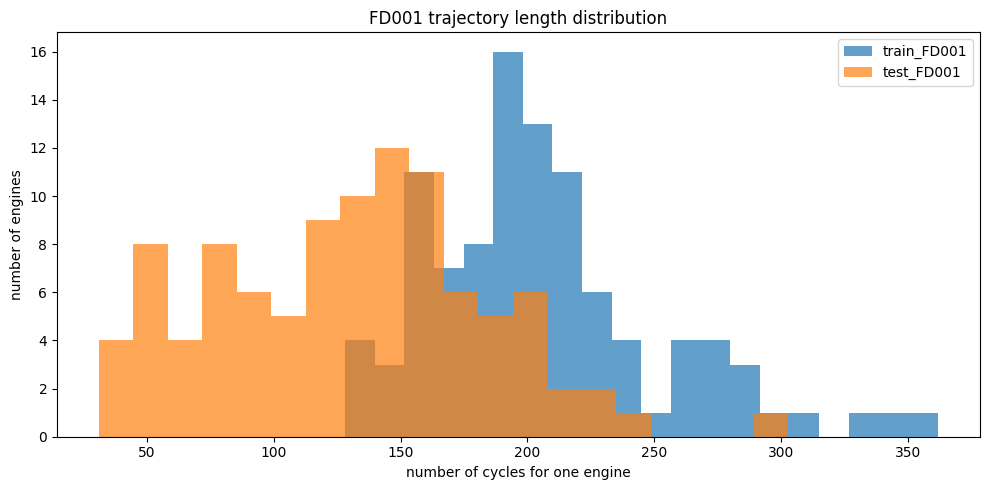

In [91]:
# Plot the distribution of trajectory lengths

plt.figure(figsize=(10, 5))
plt.hist(train_trajectory_lengths, bins=20, alpha=0.7, label="train_FD001")
plt.hist(test_trajectory_lengths, bins=20, alpha=0.7, label="test_FD001")
plt.xlabel("number of cycles for one engine")
plt.ylabel("number of engines")
plt.title("FD001 trajectory length distribution")
plt.legend()
plt.tight_layout()
if "agg" not in plt.get_backend().lower():
    plt.show()
plt.close()


In [10]:
# Sensor statistics on the training data

sensor_stats_df = train_df[sensor_cols].agg(["min", "max", "mean", "std"]).T.sort_values("std")

print("Sensors with the lowest standard deviation:")
print(sensor_stats_df.head(10).round(6).to_string())
print()
print("Sensors with the highest standard deviation:")
print(sensor_stats_df.tail(10).round(6).to_string())


Sensors with the lowest standard deviation:
           min        max         mean       std
s1    518.6700   518.6700   518.670000  0.000000
s10     1.3000     1.3000     1.300000  0.000000
s19   100.0000   100.0000   100.000000  0.000000
s18  2388.0000  2388.0000  2388.000000  0.000000
s16     0.0300     0.0300     0.030000  0.000000
s5     14.6200    14.6200    14.620000  0.000000
s6     21.6000    21.6100    21.609803  0.001389
s15     8.3249     8.5848     8.442146  0.037505
s8   2387.9000  2388.5600  2388.096652  0.070985
s13  2387.8800  2388.5600  2388.096152  0.071919

Sensors with the highest standard deviation:
         min      max         mean        std
s20    38.14    39.43    38.816271   0.180746
s11    46.85    48.53    47.541168   0.267087
s2    641.21   644.53   642.680934   0.500053
s12   518.69   523.38   521.413470   0.737553
s7    549.85   556.06   553.367711   0.885092
s17   388.00   400.00   393.210654   1.548763
s3   1571.04  1616.91  1590.523119   6.131150
s4 

In [11]:
# Identify constant and nearly constant sensors
# The small std threshold is only for inspection, not yet for dropping features.

sensor_variation_df = pd.DataFrame(
    {
        "nunique": train_df[sensor_cols].nunique(),
        "std": train_df[sensor_cols].std(),
        "min": train_df[sensor_cols].min(),
        "max": train_df[sensor_cols].max(),
    }
).sort_values(["std", "nunique"])

constant_sensors = sorted(sensor_variation_df[sensor_variation_df["nunique"] == 1].index.tolist())
nearly_constant_sensors = sorted(sensor_variation_df[(sensor_variation_df["nunique"] > 1) & (sensor_variation_df["std"] < 0.01)].index.tolist())

print("Constant sensors in FD001 train:", constant_sensors)
print("Nearly constant sensors in FD001 train (std < 0.01):", nearly_constant_sensors)
print()
print(sensor_variation_df.head(12).round(6).to_string())


Constant sensors in FD001 train: ['s1', 's10', 's16', 's18', 's19', 's5']
Nearly constant sensors in FD001 train (std < 0.01): ['s6']

     nunique       std        min        max
s1         1  0.000000   518.6700   518.6700
s10        1  0.000000     1.3000     1.3000
s18        1  0.000000  2388.0000  2388.0000
s19        1  0.000000   100.0000   100.0000
s16        1  0.000000     0.0300     0.0300
s5         1  0.000000    14.6200    14.6200
s6         2  0.001389    21.6000    21.6100
s15     1918  0.037505     8.3249     8.5848
s8        53  0.070985  2387.9000  2388.5600
s13       56  0.071919  2387.8800  2388.5600
s21     4745  0.108251    22.8942    23.6184
s20      120  0.180746    38.1400    39.4300


In [12]:
# Check how much the operational settings vary in FD001

op_settings_df = train_df[op_cols].agg(["min", "max", "mean", "std"]).T
op_settings_df["nunique"] = train_df[op_cols].nunique()

print(op_settings_df.round(6).to_string())


          min       max        mean       std  nunique
op1   -0.0087    0.0087   -0.000009  0.002187      158
op2   -0.0006    0.0006    0.000002  0.000293       13
op3  100.0000  100.0000  100.000000  0.000000        1


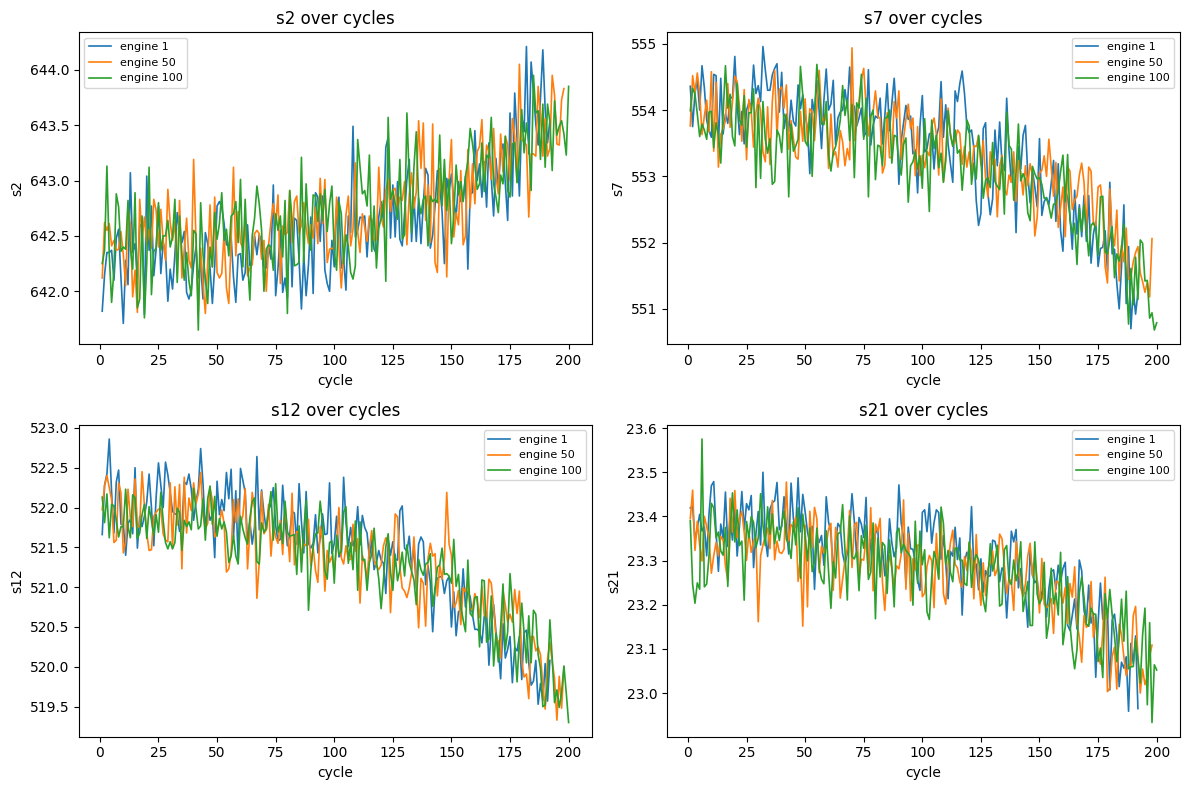

In [13]:
# Plot a few sensors over time for a few engines

selected_engines = [1, 50, 100]
selected_sensors = ["s2", "s7", "s12", "s21"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for ax, sensor in zip(axes.ravel(), selected_sensors):
    for engine in selected_engines:
        engine_df = train_df[train_df["unit"] == engine]
        ax.plot(engine_df["cycle"], engine_df[sensor], label=f"engine {engine}", linewidth=1.2)
    ax.set_title(f"{sensor} over cycles")
    ax.set_xlabel("cycle")
    ax.set_ylabel(sensor)
    ax.legend(fontsize=8)

plt.tight_layout()
if "agg" not in plt.get_backend().lower():
    plt.show()
plt.close(fig)


In [14]:
# Short interpretation of the EDA findings

print("EDA interpretation:")
print("1. FD001 has 100 train engines and 100 test engines, each represented as a time series of cycles.")
print("2. Engine lifetimes are different, so some engines fail earlier than others.")
print("3. Several sensors are constant in FD001, which means they are not useful for modeling.")
print("4. Some sensors clearly change over time, which suggests degradation is visible in the data.")
print("5. op3 is effectively constant, while op1 and op2 only vary slightly around one regime.")
print("6. This supports the idea that FD001 is a one-operating-condition subset and is a good starting point.")
print("7. The next preprocessing step should likely remove constant sensors and keep the informative varying ones.")


EDA interpretation:
1. FD001 has 100 train engines and 100 test engines, each represented as a time series of cycles.
2. Engine lifetimes are different, so some engines fail earlier than others.
3. Several sensors are constant in FD001, which means they are not useful for modeling.
4. Some sensors clearly change over time, which suggests degradation is visible in the data.
5. op3 is effectively constant, while op1 and op2 only vary slightly around one regime.
6. This supports the idea that FD001 is a one-operating-condition subset and is a good starting point.
7. The next preprocessing step should likely remove constant sensors and keep the informative varying ones.


In [15]:
# Sanity checks for the EDA results before moving on

assert train_df.shape == (20631, 26)
assert test_df.shape == (13096, 26)
assert rul_df.shape == (100, 1)

assert len(sensor_cols) == 21
assert len(op_cols) == 3

assert train_df["unit"].nunique() == 100
assert test_df["unit"].nunique() == 100

assert int(train_trajectory_lengths.min()) == 128
assert int(train_trajectory_lengths.max()) == 362
assert int(test_trajectory_lengths.min()) == 31
assert int(test_trajectory_lengths.max()) == 303

assert constant_sensors == sorted(["s1", "s5", "s10", "s16", "s18", "s19"])
assert train_df["op3"].nunique() == 1

print("Section 2 passed: the EDA results are internally consistent.")


Section 2 passed: the EDA results are internally consistent.


In [16]:
# ============================================================
# SECTION 3 - PREPROCESSING AND SENSOR SELECTION
# Choose which columns will actually be used by the model
# ============================================================

bookkeeping_cols = ["unit", "cycle"]

# For FD001, op3 is constant and op1/op2 vary only slightly around one regime.
# To keep the first version simple, we drop all three operational settings.
dropped_op_cols = ["op1", "op2", "op3"]

# From EDA: these sensors are constant or nearly constant in FD001.
dropped_sensor_cols = sorted(constant_sensors + nearly_constant_sensors)

model_feature_cols = [col for col in sensor_cols if col not in dropped_sensor_cols]
dropped_feature_cols = dropped_op_cols + dropped_sensor_cols

preprocessing_summary_df = pd.DataFrame(
    {
        "bookkeeping_columns": [", ".join(bookkeeping_cols)],
        "dropped_operational_settings": [", ".join(dropped_op_cols)],
        "dropped_sensors": [", ".join(dropped_sensor_cols)],
        "number_of_model_features": [len(model_feature_cols)],
        "kept_model_features": [", ".join(model_feature_cols)],
    }
)

print(preprocessing_summary_df.to_string(index=False))


bookkeeping_columns dropped_operational_settings                dropped_sensors  number_of_model_features                                            kept_model_features
        unit, cycle                op1, op2, op3 s1, s10, s16, s18, s19, s5, s6                        14 s2, s3, s4, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21


In [17]:
# Separate metadata from model features

train_meta_df = train_df[bookkeeping_cols].copy()
test_meta_df = test_df[bookkeeping_cols].copy()

train_features_raw_df = train_df[model_feature_cols].copy()
test_features_raw_df = test_df[model_feature_cols].copy()

print("train metadata shape:", train_meta_df.shape)
print("test metadata shape:", test_meta_df.shape)
print("train raw feature shape:", train_features_raw_df.shape)
print("test raw feature shape:", test_features_raw_df.shape)


train metadata shape: (20631, 2)
test metadata shape: (13096, 2)
train raw feature shape: (20631, 14)
test raw feature shape: (13096, 14)


In [18]:
# Standardize using training statistics only
train_feature_means = train_features_raw_df.mean()
train_feature_stds = train_features_raw_df.std()
train_feature_stds[train_feature_stds == 0] = 1.0

train_features_scaled_df = (train_features_raw_df - train_feature_means) / train_feature_stds
test_features_scaled_df = (test_features_raw_df - train_feature_means) / train_feature_stds

scaling_summary_df = pd.DataFrame(
    {
        "train_mean_before_scaling": train_feature_means,
        "train_std_before_scaling": train_feature_stds,
        "train_mean_after_scaling": train_features_scaled_df.mean(),
        "train_std_after_scaling": train_features_scaled_df.std(),
    }
)

print(scaling_summary_df.round(4).head(10).to_string())


     train_mean_before_scaling  train_std_before_scaling  train_mean_after_scaling  train_std_after_scaling
s2                    642.6809                    0.5001                       0.0                      1.0
s3                   1590.5231                    6.1311                      -0.0                      1.0
s4                   1408.9338                    9.0006                       0.0                      1.0
s7                    553.3677                    0.8851                      -0.0                      1.0
s8                   2388.0967                    0.0710                       0.0                      1.0
s9                   9065.2429                   22.0829                      -0.0                      1.0
s11                    47.5412                    0.2671                      -0.0                      1.0
s12                   521.4135                    0.7376                       0.0                      1.0
s13                  2388.09

In [19]:
# Preview the scaled modeling data

print("First 5 rows of scaled training features:")
print(train_features_scaled_df.head().round(4).to_string(index=False))
print()
print("First 5 rows of scaled test features:")
print(test_features_scaled_df.head().round(4).to_string(index=False))


First 5 rows of scaled training features:
     s2      s3      s4     s7      s8      s9     s11    s12     s13     s14     s15     s17    s20    s21
-1.7217 -0.1343 -0.9259 1.1211 -0.5163 -0.8628 -0.2665 0.3343 -1.0589 -0.2691 -0.6038 -0.7817 1.3485 1.1944
-1.0618  0.2115 -0.6437 0.4319 -0.7981 -0.9588 -0.1916 1.1749 -0.3636 -0.6428 -0.2758 -0.7817 1.0165 1.2369
-0.6618 -0.4132 -0.5259 1.0081 -0.2346 -0.5571 -1.0153 1.3647 -0.9198 -0.5516 -0.6491 -2.0730 0.7399 0.5034
-0.6618 -1.2613 -0.7848 1.2228  0.1880 -0.7138 -1.5395 1.9613 -0.2246 -0.5202 -1.9716 -0.7817 0.3526 0.7778
-0.6218 -1.2515 -0.3015 0.7144 -0.5163 -0.4570 -0.9778 1.0528 -0.7808 -0.5217 -0.3398 -0.1360 0.4632 1.0595

First 5 rows of scaled test features:
     s2      s3      s4     s7      s8      s9     s11     s12     s13     s14     s15     s17    s20    s21
 0.6781 -0.8535 -1.1915 0.6014 -0.7981 -0.6826 -1.2774  0.4156 -0.9198 -0.9542 -0.9851 -0.7817 0.2419 0.7741
-1.9417 -0.3381 -1.5014 1.6747 -1.2207 -0.4901 -0.154

In [20]:
# Sanity checks for preprocessing before moving on

assert bookkeeping_cols == ["unit", "cycle"]
assert dropped_op_cols == ["op1", "op2", "op3"]
assert dropped_sensor_cols == sorted(["s1", "s5", "s10", "s16", "s18", "s19", "s6"])

assert len(model_feature_cols) == 14
assert train_features_raw_df.shape == (20631, 14)
assert test_features_raw_df.shape == (13096, 14)

assert train_features_scaled_df.shape == train_features_raw_df.shape
assert test_features_scaled_df.shape == test_features_raw_df.shape

assert train_features_scaled_df.isna().sum().sum() == 0
assert test_features_scaled_df.isna().sum().sum() == 0

assert abs(float(train_features_scaled_df.mean().abs().max())) < 1e-10
assert abs(float((train_features_scaled_df.std() - 1).abs().max())) < 1e-10

print("Section 3 passed: feature selection and scaling are consistent.")


Section 3 passed: feature selection and scaling are consistent.


In [21]:
# ============================================================
# SECTION 4 - RUL CONSTRUCTION FOR EVALUATION
# Build row-level RUL and a simple near-failure label
# ============================================================

failure_threshold_rul = 30

# TRAIN RUL: each training engine runs until failure.
train_max_cycles = train_df.groupby("unit")["cycle"].transform("max")
train_eval_df = train_meta_df.copy()
train_eval_df["RUL"] = train_max_cycles - train_df["cycle"]

# TEST RUL: RUL file gives remaining life after the last observed cycle.
test_last_cycles_df = test_df.groupby("unit", as_index=False)["cycle"].max().rename(columns={"cycle": "last_cycle"})
rul_df_with_unit = rul_df.copy()
rul_df_with_unit["unit"] = range(1, len(rul_df_with_unit) + 1)
rul_df_with_unit = rul_df_with_unit[["unit", "RUL"]].rename(columns={"RUL": "final_rul_after_last_cycle"})

test_rul_lookup_df = test_last_cycles_df.merge(rul_df_with_unit, on="unit", how="left")
test_eval_df = test_meta_df.merge(test_rul_lookup_df, on="unit", how="left")
test_eval_df["RUL"] = test_eval_df["final_rul_after_last_cycle"] + (test_eval_df["last_cycle"] - test_eval_df["cycle"])

train_eval_df["is_near_failure"] = (train_eval_df["RUL"] <= failure_threshold_rul).astype(int)
test_eval_df["is_near_failure"] = (test_eval_df["RUL"] <= failure_threshold_rul).astype(int)

print("failure threshold RUL:", failure_threshold_rul)


failure threshold RUL: 30


In [22]:
# Preview train and test row-level RUL

print("Train evaluation preview:")
print(train_eval_df.head(10).to_string(index=False))
print()
print("Test evaluation preview:")
print(test_eval_df.head(10).to_string(index=False))
print()
print("Test RUL lookup preview:")
print(test_rul_lookup_df.head(10).to_string(index=False))


Train evaluation preview:
 unit  cycle  RUL  is_near_failure
    1      1  191                0
    1      2  190                0
    1      3  189                0
    1      4  188                0
    1      5  187                0
    1      6  186                0
    1      7  185                0
    1      8  184                0
    1      9  183                0
    1     10  182                0

Test evaluation preview:
 unit  cycle  last_cycle  final_rul_after_last_cycle  RUL  is_near_failure
    1      1          31                         112  142                0
    1      2          31                         112  141                0
    1      3          31                         112  140                0
    1      4          31                         112  139                0
    1      5          31                         112  138                0
    1      6          31                         112  137                0
    1      7          31              

In [23]:
# Summary tables for RUL and near-failure labels

train_rul_summary_df = train_eval_df["RUL"].describe().round(2).to_frame(name="train_RUL")
test_rul_summary_df = test_eval_df["RUL"].describe().round(2).to_frame(name="test_RUL")

label_summary_df = pd.DataFrame(
    {
        "dataset": ["train_FD001", "test_FD001"],
        "rows": [len(train_eval_df), len(test_eval_df)],
        "near_failure_rows": [int(train_eval_df["is_near_failure"].sum()), int(test_eval_df["is_near_failure"].sum())],
        "normal_rows": [int((train_eval_df["is_near_failure"] == 0).sum()), int((test_eval_df["is_near_failure"] == 0).sum())],
    }
)

print("Train RUL summary:")
print(train_rul_summary_df.to_string())
print()
print("Test RUL summary:")
print(test_rul_summary_df.to_string())
print()
print("Near-failure label summary:")
print(label_summary_df.to_string(index=False))


Train RUL summary:
       train_RUL
count   20631.00
mean      107.81
std        68.88
min         0.00
25%        51.00
50%       103.00
75%       155.00
max       361.00

Test RUL summary:
       test_RUL
count  13096.00
mean     141.24
std       58.98
min        7.00
25%      102.00
50%      140.00
75%      179.00
max      340.00

Near-failure label summary:
    dataset  rows  near_failure_rows  normal_rows
train_FD001 20631               3100        17531
 test_FD001 13096                332        12764


In [24]:
# Short interpretation of the RUL construction step

print("RUL interpretation:")
print("1. For training engines, RUL is easy to compute because each engine runs all the way to failure.")
print("2. For test engines, the provided RUL file tells us how many cycles are left after the last observed cycle.")
print("3. Once row-level RUL is built, every cycle can be labeled by how close it is to failure.")
print("4. We are using RUL <= 30 as a simple near-failure region for evaluation.")
print("5. These labels are for evaluation only, not for training the anomaly detector.")


RUL interpretation:
1. For training engines, RUL is easy to compute because each engine runs all the way to failure.
2. For test engines, the provided RUL file tells us how many cycles are left after the last observed cycle.
3. Once row-level RUL is built, every cycle can be labeled by how close it is to failure.
4. We are using RUL <= 30 as a simple near-failure region for evaluation.
5. These labels are for evaluation only, not for training the anomaly detector.


In [25]:
# Sanity checks for RUL construction before moving on

assert failure_threshold_rul == 30

assert train_eval_df.shape[0] == len(train_df)
assert test_eval_df.shape[0] == len(test_df)

assert int(train_eval_df["RUL"].min()) == 0
assert int(test_eval_df["RUL"].min()) > 0

assert int(train_eval_df.loc[(train_eval_df["unit"] == 1) & (train_eval_df["cycle"] == 192), "RUL"].iloc[0]) == 0
assert int(test_eval_df.loc[(test_eval_df["unit"] == 1) & (test_eval_df["cycle"] == 31), "RUL"].iloc[0]) == 112
assert int(test_eval_df.loc[(test_eval_df["unit"] == 1) & (test_eval_df["cycle"] == 1), "RUL"].iloc[0]) == 142

assert train_eval_df["is_near_failure"].isin([0, 1]).all()
assert test_eval_df["is_near_failure"].isin([0, 1]).all()

assert train_eval_df[["unit", "cycle", "RUL"]].isna().sum().sum() == 0
assert test_eval_df[["unit", "cycle", "RUL"]].isna().sum().sum() == 0

print("Section 4 passed: row-level RUL and evaluation labels are consistent.")


Section 4 passed: row-level RUL and evaluation labels are consistent.


In [26]:
# ============================================================
# SECTION 5 - CREATE SLIDING WINDOWS
# Step 5: convert row-by-row time series into short sequences
# ============================================================

import numpy as np

WINDOW_LENGTH = 30
STRIDE = 1
HEALTHY_MAX_CYCLE = 50

def create_sliding_windows(feature_df, eval_df, window_length=30, stride=1):
    """
    Create sliding windows per engine without mixing engines.

    Each window stores:
    - input values
    - engine ID
    - start cycle
    - end cycle
    - RUL at the end of the window
    - near-failure label at the end of the window
    """

    X_windows = []
    meta_rows = []

    combined_df = pd.concat(
        [
            eval_df[["unit", "cycle", "RUL", "is_near_failure"]].reset_index(drop=True),
            feature_df.reset_index(drop=True),
        ],
        axis=1,
    )

    feature_columns = feature_df.columns.tolist()

    for unit, unit_df in combined_df.groupby("unit", sort=True):
        unit_df = unit_df.sort_values("cycle").reset_index(drop=True)
        feature_values = unit_df[feature_columns].to_numpy(dtype=np.float32)

        for start_idx in range(0, len(unit_df) - window_length + 1, stride):
            end_idx = start_idx + window_length - 1

            window = feature_values[start_idx : start_idx + window_length]
            start_row = unit_df.iloc[start_idx]
            end_row = unit_df.iloc[end_idx]

            X_windows.append(window)
            meta_rows.append(
                {
                    "unit": int(unit),
                    "start_cycle": int(start_row["cycle"]),
                    "end_cycle": int(end_row["cycle"]),
                    "RUL": int(end_row["RUL"]),
                    "is_near_failure": int(end_row["is_near_failure"]),
                }
            )

    X = np.stack(X_windows).astype(np.float32)
    meta_df = pd.DataFrame(meta_rows)

    return X, meta_df


X_train_windows, train_window_meta_df = create_sliding_windows(
    train_features_scaled_df,
    train_eval_df,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
)

X_test_windows, test_window_meta_df = create_sliding_windows(
    test_features_scaled_df,
    test_eval_df,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
)

window_summary_df = pd.DataFrame(
    {
        "dataset": ["train_FD001", "test_FD001"],
        "windows": [len(X_train_windows), len(X_test_windows)],
        "window_shape": [str(X_train_windows.shape[1:]), str(X_test_windows.shape[1:])],
        "engines": [train_window_meta_df["unit"].nunique(), test_window_meta_df["unit"].nunique()],
        "window_length": [WINDOW_LENGTH, WINDOW_LENGTH],
        "stride": [STRIDE, STRIDE],
    }
)

print(window_summary_df.to_string(index=False))
print()
print("Train window metadata preview:")
print(train_window_meta_df.head().to_string(index=False))
print()
print("Test window metadata preview:")
print(test_window_meta_df.head().to_string(index=False))

assert X_train_windows.shape[1] == WINDOW_LENGTH
assert X_test_windows.shape[1] == WINDOW_LENGTH
assert X_train_windows.shape[2] == len(model_feature_cols)
assert X_test_windows.shape[2] == len(model_feature_cols)

assert train_window_meta_df[["unit", "start_cycle", "end_cycle", "RUL"]].isna().sum().sum() == 0
assert test_window_meta_df[["unit", "start_cycle", "end_cycle", "RUL"]].isna().sum().sum() == 0

assert (train_window_meta_df["end_cycle"] - train_window_meta_df["start_cycle"] + 1).eq(WINDOW_LENGTH).all()
assert (test_window_meta_df["end_cycle"] - test_window_meta_df["start_cycle"] + 1).eq(WINDOW_LENGTH).all()

print("\nStep 5 passed: sliding windows were created without mixing engines.")

    dataset  windows window_shape  engines  window_length  stride
train_FD001    17731     (30, 14)      100             30       1
 test_FD001    10196     (30, 14)      100             30       1

Train window metadata preview:
 unit  start_cycle  end_cycle  RUL  is_near_failure
    1            1         30  162                0
    1            2         31  161                0
    1            3         32  160                0
    1            4         33  159                0
    1            5         34  158                0

Test window metadata preview:
 unit  start_cycle  end_cycle  RUL  is_near_failure
    1            1         30  113                0
    1            2         31  112                0
    2            1         30  117                0
    2            2         31  116                0
    2            3         32  115                0

Step 5 passed: sliding windows were created without mixing engines.


In [27]:
# ============================================================
# SECTION 6 - SELECT HEALTHY TRAINING WINDOWS
# Step 6: keep only early-life windows for anomaly-detector training
# ============================================================

# Healthy rule:
# A training window is considered healthy if its END cycle is within the first 50 cycles.
# With a 30-cycle window, this means windows ending at cycles 30, 31, ..., 50.

healthy_mask = train_window_meta_df["end_cycle"] <= HEALTHY_MAX_CYCLE

X_healthy_windows = X_train_windows[healthy_mask.to_numpy()]
healthy_window_meta_df = train_window_meta_df.loc[healthy_mask].reset_index(drop=True)

healthy_summary_df = pd.DataFrame(
    {
        "healthy_rule": [f"end_cycle <= {HEALTHY_MAX_CYCLE}"],
        "healthy_windows": [len(X_healthy_windows)],
        "engines_used": [healthy_window_meta_df["unit"].nunique()],
        "window_length": [WINDOW_LENGTH],
        "stride": [STRIDE],
        "features_per_cycle": [len(model_feature_cols)],
    }
)

print(healthy_summary_df.to_string(index=False))
print()
print("Healthy window metadata preview:")
print(healthy_window_meta_df.head().to_string(index=False))
print()
print(
    "Healthy end-cycle range:",
    int(healthy_window_meta_df["end_cycle"].min()),
    "to",
    int(healthy_window_meta_df["end_cycle"].max()),
)

assert len(X_healthy_windows) == 100 * (HEALTHY_MAX_CYCLE - WINDOW_LENGTH + 1)
assert healthy_window_meta_df["unit"].nunique() == 100
assert healthy_window_meta_df["end_cycle"].max() <= HEALTHY_MAX_CYCLE
assert healthy_window_meta_df["is_near_failure"].sum() == 0

print("\nStep 6 passed: healthy training windows are ready.")

   healthy_rule  healthy_windows  engines_used  window_length  stride  features_per_cycle
end_cycle <= 50             2100           100             30       1                  14

Healthy window metadata preview:
 unit  start_cycle  end_cycle  RUL  is_near_failure
    1            1         30  162                0
    1            2         31  161                0
    1            3         32  160                0
    1            4         33  159                0
    1            5         34  158                0

Healthy end-cycle range: 30 to 50

Step 6 passed: healthy training windows are ready.


In [109]:
# ============================================================
# SECTION 8 - LSTM AUTOENCODER
# To be completed after the baseline
# ============================================================

print("Section 6 placeholder: ready for the LSTM autoencoder.")


Section 6 placeholder: ready for the LSTM autoencoder.


In [110]:
# ============================================================
# SECTION 7 - EVALUATION AND VISUALIZATIONS
# To be completed after model training
# ============================================================

print("Section 7 placeholder: ready for evaluation and plots.")


Section 7 placeholder: ready for evaluation and plots.
